# Image Similarity Analysis: Using VLAD and Fisher Vector Encoders

Welcome to the guide on using the `VLAD` and `FisherVector` encoders for image similarity analysis. Here, we will walk through the following steps:

1. Initializing an encoder (VLAD or Fisher Vector).
2. Training the encoder using the `learn` method.
3. Using pre-trained PCA and clustering models (KMeans/GMM), saving them, and loading them for reuse.
4. Encoding images and computing similarities.

## 1. Setting Up

Let's begin by importing the necessary modules and preparing our environment.

### Required Imports and Configuration

In [ ]:
from itertools import islice

from pyvisim._utils import plot_image
from pyvisim.datasets import OxfordFlowerDataset
from pyvisim.encoders import FisherVectorEncoder, VLADEncoder
from pyvisim.features import SIFT

### Set number of clusters for KMeans or GMM

Set `k` lower if you run into runtime issues, but VLAD and Fisher Vector encoders benefit from a higher number of clusters.

In [5]:
k = 32

## 2. Initializing an Encoder

### Example: Initializing a VLAD Encoder with RootSIFT Features

Since the default feature extractor for VLAD is RootSIFT, we can directly initialize the encoder without specifying the feature extractor.


In [6]:
# Initialize a VLAD encoder
vlad_encoder = VLADEncoder(n_clusters=k)
print("Feature extractor:", vlad_encoder.feature_extractor)

Feature extractor: RootSIFT(output_dim=128)



### Example: Initializing a Fisher Vector Encoder with SIFT Features


In [7]:
# Initialize a RootSIFT feature extractor
feature_extractor = SIFT()

# Initialize a Fisher Vector encoder
fisher_encoder = FisherVectorEncoder(
    feature_extractor=feature_extractor, n_components=k
)


## 3. Training the Encoder Using the `learn` Method

The `learn` method trains the clustering model (KMeans for VLAD or GMM for Fisher Vector) and optionally applies PCA for dimensionality reduction.

### Example: Training a VLAD Encoder


In [8]:
# Load sample images from the Oxford Flower dataset
dataset = OxfordFlowerDataset()
images = [
    image for i, (image, *_) in enumerate(islice(dataset, 200))
]  # Set '200' to len(dataset) for full dataset

In [13]:
# Train the encoder with KMeans clustering
vlad_encoder.learn(images, dim_reduction_factor=2)
vlad_encoder.save_to_disk("vlad_encoder")

[INFO] Learning the visual vocabulary with the following parameters:
   - Number of clusters: 32
   - Feature Extractor used: RootSIFT
   - Dimension of the feature space: 128
   - New dimension after PCA reduction: 64


PosixPath('vlad_encoder.encoder')

### Example: Training a Fisher Vector Encoder

**NOTE**: Fisher Vectors are inherintly more high-dimensional than VLAD, so the computation may take a while.


In [30]:
# Train the encoder with GMM clustering
fisher_encoder.learn(images, dim_reduction_factor=2)
fisher_encoder.save_to_disk("fisher_encoder")

[INFO] Learning the visual vocabulary with the following parameters:
   - Number of clusters: 32
   - Feature Extractor used: RootSIFT
   - Dimension of the feature space: 128
   - New dimension after PCA reduction: 64


PosixPath('fisher_encoder.encoder')


## 4. Encoding Images and Computing Similarities


If you saved an encoder to disk after training, you can load it back like this. Simply uncomment the two lines below:

In [ ]:
# vlad_encoder = VLADEncoder.load_from_disk("vlad_encoder.encoder")
# fisher_encoder = FisherVectorEncoder.load_from_disk("fisher_encoder.encoder")

### Example: Encoding Images

We will convert all images from the dataset batch above to encoding representations (which is basically the numerical representation of the image using the algorithm of the encoder).

In [24]:
image_encodings_vlad = vlad_encoder.encode(images)
print("Shape of VLAD encodings:", image_encodings_vlad.shape)

Shape of VLAD encodings: (200, 2048)


In [25]:
image_encodings_fisher = fisher_encoder.encode(images)
print("Shape of Fisher Vector encodings:", image_encodings_fisher.shape)

Shape of Fisher Vector encodings: (200, 4128)



### Example: Computing Similarity Between Two Images

First, we choose and plot the images to compare.

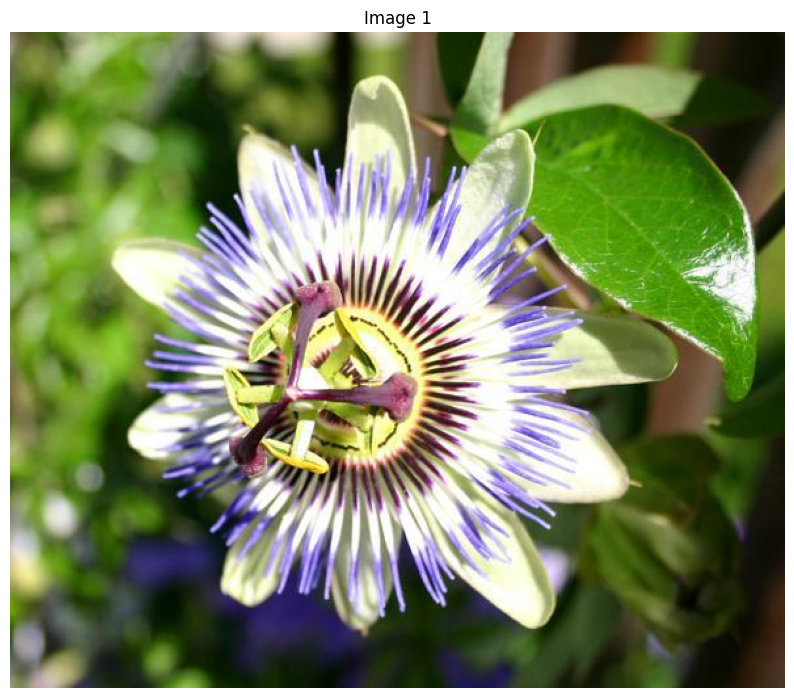

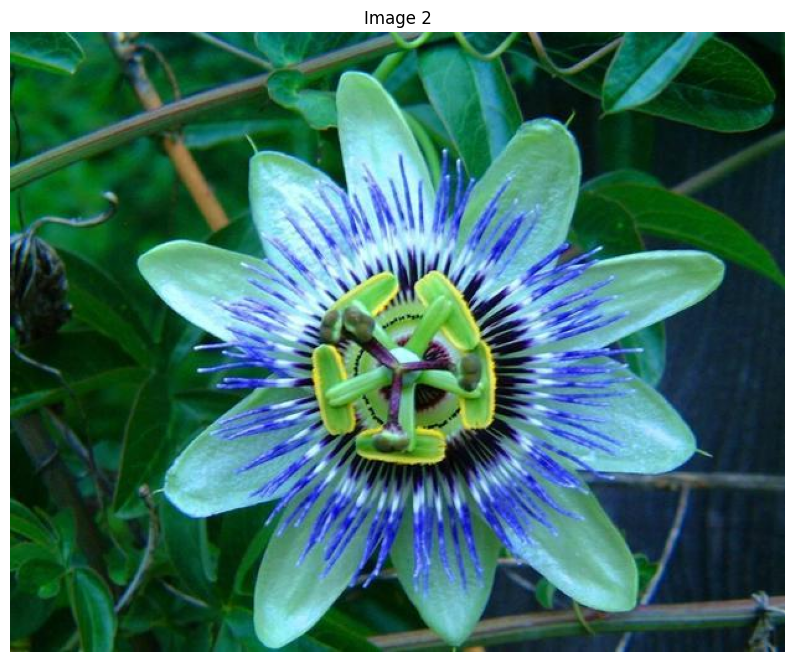

In [26]:
image_1, image_2 = images[0], images[1]
plot_image(image_1, title="Image 1")
plot_image(image_2, title="Image 2")

In [27]:
# Compute similarity using VLAD encoder
similarity = vlad_encoder.similarity_score(image_1, image_2)

print("Similarity score:", similarity)

Similarity score: [[0.15482144]]


In [31]:
# Compute similarity using Fisher Vector encoder
similarity = fisher_encoder.similarity_score(image_1, image_2)

print("Similarity score:", similarity)

Similarity score: [[0.11328945]]
